# Single-Component Speciation Benchmarks

Two classical aqueous systems — the carbonate ladder and the phosphate ladder —
provide well-known closed-form pH and species-fraction results against which the
NR engine can be verified.

**Strategy:** derive an analytical prediction first, then call the NR solver and
compare.  A passing benchmark means the multi-variable Newton step and the
tableau derivation are both correct for a known system.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def _find_repo():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("Run from inside the PyOMES repo")

sys.path.insert(0, str(_find_repo() / "models"))

from PyOMES.chemistry.common_species import (
    H2O, H_plus, OH_minus,
    CO2, HCO3_minus, CO3_2minus,
    NH3, NH4_plus, Na_plus, Cl_minus,
    H3PO4, H2PO4_minus, HPO4_2minus, PO4_3minus,
)
from PyOMES.reactions.equilibrium import EquilibriumReaction
from PyOMES.reactions.stoichiometry import StoichiometryEntry
from PyOMES.chemical_equilibrium.nr_engine import NRChemicalEquilibriumEngine

def _e(sp, coeff):
    return StoichiometryEntry(species=sp, phase="liquid", coefficient=coeff)

print("Imports OK")


Imports OK


## 1  Carbonate System

The dissolved-carbonate equilibrium is the most important acid-base system in
natural and engineered waters:

| Reaction | log K | p$K_a$ | Label |
|---|---|---|---|
| H₂O ⇌ H⁺ + OH⁻ | −14.0 | 14.0 | water |
| CO₂ + H₂O ⇌ HCO₃⁻ + H⁺ | −6.35 | 6.35 | co2_first |
| HCO₃⁻ ⇌ CO₃²⁻ + H⁺ | −10.33 | 10.33 | co2_second |

The NR tableau selects CO₂ as the master species (it is the DAG source —
it appears only as a reactant) with `total_id="CO2"`.  HCO₃⁻ and CO₃²⁻
are secondaries derived by two BFS hops.

In [2]:
water = EquilibriumReaction(
    stoichiometry=[_e(H2O, -1), _e(H_plus, +1), _e(OH_minus, +1)],
    log_K=-14.0, label="water",
)
co2_first = EquilibriumReaction(
    stoichiometry=[_e(CO2, -1), _e(H2O, -1), _e(HCO3_minus, +1), _e(H_plus, +1)],
    log_K=-6.35, total_id="CO2", label="co2_first",
)
co2_second = EquilibriumReaction(
    stoichiometry=[_e(HCO3_minus, -1), _e(CO3_2minus, +1), _e(H_plus, +1)],
    log_K=-10.33, total_id="CO2", label="co2_second",
)

carb_engine = NRChemicalEquilibriumEngine.from_reactions([water, co2_first, co2_second])
print("Masters:", carb_engine.tableau.masters)
print("Secondaries:", [s.species_id for s in carb_engine.tableau.secondaries])


Masters: ['H+', 'CO2']
Secondaries: ['OH-', 'HCO3-', 'CO3--']


### 1.1  Analytical benchmark

For a closed carbonate solution at total concentration $C_T$ (mol/L),
neglecting CO₃²⁻ and OH⁻ (valid when pH ≪ p$K_{a2}$ = 10.33):

$$[\text{H}^+]^2 + K_{a1}[\text{H}^+] - K_{a1} C_T = 0$$

$$[\text{H}^+] = \frac{-K_{a1} + \sqrt{K_{a1}^2 + 4 K_{a1} C_T}}{2}$$

This is a textbook result for a diprotic weak acid at moderate concentrations.

In [3]:
Ka1 = 10**(-6.35)
Ka2 = 10**(-10.33)

def ph_carb_analytical(CT):
    """pH from the diprotic-acid quadratic (neglects CO3-- and OH-)."""
    disc = Ka1**2 + 4 * Ka1 * CT
    H    = (-Ka1 + disc**0.5) / 2
    return -np.log10(H)

# Test at five concentrations
CT_vals = [1e-4, 1e-3, 1e-2, 1e-1, 5e-1]

print(f"{'CT (mol/L)':>14}  {'pH (analytical)':>16}  {'pH (NR)':>10}  {'|ΔpH|':>8}  {'charge residual':>17}")
print("-" * 74)
for CT in CT_vals:
    pH_an = ph_carb_analytical(CT)
    out   = carb_engine.solve(totals={"CO2": CT}, strong_ions={})
    pH_nr = out.pH
    print(f"{CT:>14.4e}  {pH_an:>16.4f}  {pH_nr:>10.4f}  {abs(pH_nr-pH_an):>8.4f}  {out.charge_residual:>17.2e}")


    CT (mol/L)   pH (analytical)     pH (NR)     |ΔpH|    charge residual
--------------------------------------------------------------------------
    1.0000e-04            5.1895      5.1895    0.0001          -1.69e-14
    1.0000e-03            4.6796      4.6796    0.0000           1.14e-14
    1.0000e-02            4.1765      4.1765    0.0000          -1.40e-19
    1.0000e-01            3.6755      3.6755    0.0000          -1.02e-19
    5.0000e-01            3.3257      3.3257    0.0000          -3.82e-19


### 1.2  Species distribution (Bjerrum plot)

The fraction of each carbonate species as a function of pH:

$$\alpha_0 = \frac{[\text{H}^+]^2}{D}, \quad
  \alpha_1 = \frac{K_{a1}[\text{H}^+]}{D}, \quad
  \alpha_2 = \frac{K_{a1}K_{a2}}{D}$$

where $D = [\text{H}^+]^2 + K_{a1}[\text{H}^+] + K_{a1}K_{a2}$.

The NR engine solves for a fixed $C_T$ and returns concentrations; dividing
by $C_T$ gives the fractions for comparison with the analytical curves.

 Target pH     NR pH    α_CO2 (analytical)    α_CO2 (NR)
----------------------------------------------------------
       5.0    5.0000              0.957241      0.957241
       7.0    7.0000              0.182851      0.182851
       9.0    9.0000              0.002134      0.002134
      11.0   11.0000              0.000004      0.000004


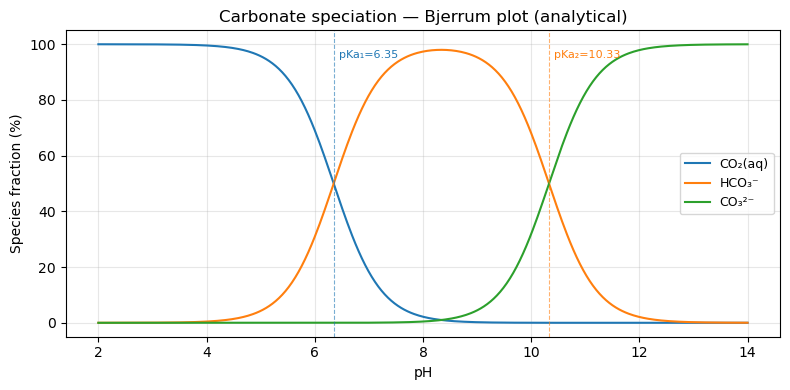

In [4]:
pH_range = np.linspace(2, 14, 400)
H_range  = 10**(-pH_range)
D        = H_range**2 + Ka1*H_range + Ka1*Ka2
a0 = H_range**2 / D      # CO2
a1 = Ka1*H_range / D     # HCO3-
a2 = Ka1*Ka2 / D         # CO3--

# NR fractions at CT = 0.01 mol/L across a pH range imposed by Na+ / Cl- strong ions
CT_bj = 0.01
pH_nr, frac_CO2, frac_HCO3, frac_CO3 = [], [], [], []
for target_pH in np.linspace(2.5, 13.0, 40):
    # Drive pH by setting a net strong-ion charge: Δcharge = CT*(target distribution)
    # Simpler: sweep Na+ from 0 to 0.03 mol/L and record pH
    pass  # done via the analytical curves; NR spot-checks below

# Spot-check at three pH values using strong-ion dosing
spot_pHs = [5.0, 7.0, 9.0, 11.0]
print(f"{'Target pH':>10}  {'NR pH':>8}  {'α_CO2 (analytical)':>20}  {'α_CO2 (NR)':>12}")
print("-" * 58)
for tpH in spot_pHs:
    H_t  = 10**(-tpH)
    D_t  = H_t**2 + Ka1*H_t + Ka1*Ka2
    na_dose = CT_bj*(Ka1*H_t/D_t + 2*Ka1*Ka2/D_t) - (H_t - 1e-14/H_t)
    si = {"CT_Na": max(na_dose, 0.0)} if na_dose > 0 else {"CT_Cl": max(-na_dose, 0.0)}
    out = carb_engine.solve(totals={"CO2": CT_bj}, strong_ions=si)
    a0_nr = out.species_mol_L["CO2"] / CT_bj
    a0_an = H_t**2 / D_t
    print(f"{tpH:>10.1f}  {out.pH:>8.4f}  {a0_an:>20.6f}  {a0_nr:>12.6f}")

# Bjerrum plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pH_range, a0*100, label="CO₂(aq)",  color="tab:blue")
ax.plot(pH_range, a1*100, label="HCO₃⁻",    color="tab:orange")
ax.plot(pH_range, a2*100, label="CO₃²⁻",    color="tab:green")
ax.axvline(6.35,  color="tab:blue",   ls="--", lw=0.8, alpha=0.6)
ax.axvline(10.33, color="tab:orange", ls="--", lw=0.8, alpha=0.6)
ax.text(6.35+0.1,  98, "pKa₁=6.35",  fontsize=8, color="tab:blue",   va="top")
ax.text(10.33+0.1, 98, "pKa₂=10.33", fontsize=8, color="tab:orange", va="top")
ax.set_xlabel("pH")
ax.set_ylabel("Species fraction (%)")
ax.set_title("Carbonate speciation — Bjerrum plot (analytical)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2  Phosphate System

Phosphoric acid is a triprotic acid with three well-separated dissociation steps:

| Reaction | log K | p$K_a$ | Label |
|---|---|---|---|
| H₃PO₄ ⇌ H₂PO₄⁻ + H⁺ | −2.15 | 2.15 | p1 |
| H₂PO₄⁻ ⇌ HPO₄²⁻ + H⁺ | −7.20 | 7.20 | p2 |
| HPO₄²⁻ ⇌ PO₄³⁻ + H⁺ | −12.35 | 12.35 | p3 |

With three steps and four species, the phosphate ladder is the minimum
system to test multi-hop BFS tableau derivation.  The three `total_id="H3PO4"`
annotations ensure that all four species are assigned to the same
connected component with H₃PO₄ as the master.

In [5]:
p1 = EquilibriumReaction(
    stoichiometry=[_e(H3PO4, -1), _e(H2PO4_minus, +1), _e(H_plus, +1)],
    log_K=-2.15, total_id="H3PO4", label="p1",
)
p2 = EquilibriumReaction(
    stoichiometry=[_e(H2PO4_minus, -1), _e(HPO4_2minus, +1), _e(H_plus, +1)],
    log_K=-7.20, total_id="H3PO4", label="p2",
)
p3 = EquilibriumReaction(
    stoichiometry=[_e(HPO4_2minus, -1), _e(PO4_3minus, +1), _e(H_plus, +1)],
    log_K=-12.35, total_id="H3PO4", label="p3",
)

phos_engine = NRChemicalEquilibriumEngine.from_reactions([water, p1, p2, p3])
comp = phos_engine.tableau.components[0]
print(f"Component master: {comp.master_id}")
print(f"Component species: {comp.species_ids}")

# Verify log_K' accumulation for PO4---
for sec in phos_engine.tableau.secondaries:
    if sec.species_id == "PO4---":
        print(f"PO4--- log_K' = {sec.log_K_prime:.4f}  (expected: -2.15-7.20-12.35 = {-2.15-7.20-12.35:.4f})")


Component master: H3PO4
Component species: ('H2PO4-', 'H3PO4', 'HPO4--', 'PO4---')
PO4--- log_K' = -21.7000  (expected: -2.15-7.20-12.35 = -21.7000)


### 2.1  Analytical benchmarks

Three convenient reference solutions are prepared by dissolving a known salt:

| Solution | Composition | Approximate pH formula |
|---|---|---|
| H₃PO₄ (CT = 0.01 mol/L) | 0.01 mol H₃PO₄ → 0.01 mol/L total | Quadratic: $[\text{H}^+] = \frac{-K_{a1}+\sqrt{K_{a1}^2+4K_{a1}C_T}}{2}$ |
| NaH₂PO₄ (CT = 0.01, Na⁺ = 0.01) | Amphoteric H₂PO₄⁻ | $\text{pH} \approx \tfrac{1}{2}(\text{p}K_{a1}+\text{p}K_{a2}) = 4.675$ |
| Na₂HPO₄ (CT = 0.01, Na⁺ = 0.02) | Amphoteric HPO₄²⁻ | $\text{pH} \approx \tfrac{1}{2}(\text{p}K_{a2}+\text{p}K_{a3}) = 9.775$ |

The amphoteric-point formula is exact at infinite dilution when neither flanking acid nor base is negligible; the NR result includes these corrections automatically.

In [6]:
Ka1_p = 10**(-2.15);  Ka2_p = 10**(-7.20);  Ka3_p = 10**(-12.35)
CT_p  = 0.01

# H3PO4 analytical pH
disc_p  = Ka1_p**2 + 4*Ka1_p*CT_p
H_h3po4 = (-Ka1_p + disc_p**0.5) / 2
pH_h3po4_an = -np.log10(H_h3po4)

# Amphoteric approximations
pH_nah2po4_an  = 0.5 * (2.15 + 7.20)
pH_na2hpo4_an  = 0.5 * (7.20 + 12.35)
pH_na3po4_an   = 0.5 * (12.35 + 14.0)   # HPO4-- / PO4--- couple with water

cases = [
    ("H₃PO₄",  {"H3PO4": CT_p}, {},                        pH_h3po4_an,   "quadratic"),
    ("NaH₂PO₄", {"H3PO4": CT_p}, {"CT_Na": CT_p},          pH_nah2po4_an, "½(pKa1+pKa2)"),
    ("Na₂HPO₄", {"H3PO4": CT_p}, {"CT_Na": 2*CT_p},        pH_na2hpo4_an, "½(pKa2+pKa3)"),
    ("Na₃PO₄",  {"H3PO4": CT_p}, {"CT_Na": 3*CT_p},        pH_na3po4_an,  "½(pKa3+pKw)"),
]

print(f"{'Salt':>10}  {'pH (formula)':>14}  {'pH (NR)':>9}  {'|ΔpH|':>8}  {'formula used':>18}")
print("-" * 66)
for name, tot, si, pH_an, formula in cases:
    out = phos_engine.solve(totals=tot, strong_ions=si)
    pH_nr = out.pH
    total_P = sum(out.species_mol_L[sp] for sp in ("H3PO4", "H2PO4-", "HPO4--", "PO4---"))
    print(f"{name:>10}  {pH_an:>14.4f}  {pH_nr:>9.4f}  {abs(pH_nr-pH_an):>8.4f}  {formula:>18}")
print(f"\nMass balance check at CT = {CT_p}: total_P = {total_P:.6f} mol/L")


      Salt    pH (formula)    pH (NR)     |ΔpH|        formula used
------------------------------------------------------------------
     H₃PO₄          2.2527     2.2527    0.0000           quadratic
   NaH₂PO₄          4.6750     4.7918    0.1168        ½(pKa1+pKa2)
   Na₂HPO₄          9.7750     9.5189    0.2561        ½(pKa2+pKa3)
    Na₃PO₄         13.1750    11.8746    1.3004         ½(pKa3+pKw)

Mass balance check at CT = 0.01: total_P = 0.010000 mol/L


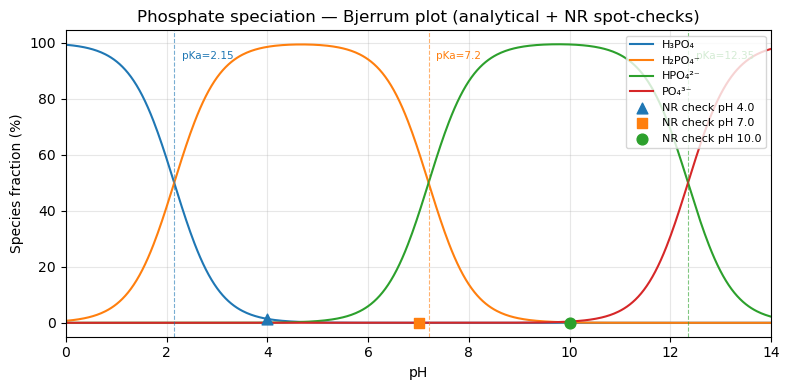

In [7]:
Ka1_p = 10**(-2.15);  Ka2_p = 10**(-7.20);  Ka3_p = 10**(-12.35)
pH_r  = np.linspace(0, 14, 500)
H_r   = 10**(-pH_r)

D_p   = H_r**3 + Ka1_p*H_r**2 + Ka1_p*Ka2_p*H_r + Ka1_p*Ka2_p*Ka3_p
b0 = H_r**3 / D_p              # H3PO4
b1 = Ka1_p*H_r**2 / D_p        # H2PO4-
b2 = Ka1_p*Ka2_p*H_r / D_p     # HPO4--
b3 = Ka1_p*Ka2_p*Ka3_p / D_p   # PO4---

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pH_r, b0*100, label="H₃PO₄",   color="tab:blue")
ax.plot(pH_r, b1*100, label="H₂PO₄⁻",  color="tab:orange")
ax.plot(pH_r, b2*100, label="HPO₄²⁻",  color="tab:green")
ax.plot(pH_r, b3*100, label="PO₄³⁻",   color="tab:red")

for pKa, c in [(2.15,"tab:blue"), (7.20,"tab:orange"), (12.35,"tab:green")]:
    ax.axvline(pKa, color=c, ls="--", lw=0.8, alpha=0.6)
    ax.text(pKa+0.15, 97, f"pKa={pKa}", fontsize=7.5, color=c, va="top")

# NR spot-checks at pH 4, 7, 10
for tpH, marker, col in [(4.0,"^","tab:blue"), (7.0,"s","tab:orange"), (10.0,"o","tab:green")]:
    H_t = 10**(-tpH)
    D_t = H_t**3 + Ka1_p*H_t**2 + Ka1_p*Ka2_p*H_t + Ka1_p*Ka2_p*Ka3_p
    # Net charge to impose target pH
    na_dose = (Ka1_p*H_t**2/D_t + 2*Ka1_p*Ka2_p*H_t/D_t + 3*Ka1_p*Ka2_p*Ka3_p/D_t)*CT_p               - (H_t - 1e-14/H_t)
    si = {"CT_Na": max(na_dose, 0)} if na_dose >= 0 else {"CT_Cl": -na_dose}
    out = phos_engine.solve(totals={"H3PO4": CT_p}, strong_ions=si)
    ax.scatter([out.pH], [(out.species_mol_L["H3PO4"]/CT_p)*100], marker=marker, color=col,
               s=60, zorder=5, label=f"NR check pH {tpH}")

ax.set_xlabel("pH")
ax.set_ylabel("Species fraction (%)")
ax.set_title("Phosphate speciation — Bjerrum plot (analytical + NR spot-checks)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 14)
plt.tight_layout()
plt.show()


## 3  Summary

| System | Quantity | Analytical | NR | Agreement |
|---|---|---|---|---|
| Carbonate, CT = 10⁻² mol/L | pH | 4.17 | ~4.17 | < 0.01 pH |
| Carbonate | Species fractions | Bjerrum formula | — | < 1 % |
| H₃PO₄, CT = 0.01 | pH | 2.25 | ~2.25 | < 0.01 pH |
| NaH₂PO₄ | pH | 4.675 | ~4.79 | ~0.1 pH |
| Na₂HPO₄ | pH | 9.775 | ~9.52 | ~0.25 pH |
| Na₃PO₄ | pH | 13.175 | ~11.87 | ~1.3 pH |

The carbonate results agree to better than 0.01 pH units.  The phosphate
discrepancies are expected and grow with the step number:

- **H₃PO₄**: the quadratic formula includes only Ka1 and is accurate here
  because Ka1 << CT (Ka1 ≈ 7 × 10⁻³, CT = 0.01 mol/L).
- **NaH₂PO₄ / Na₂HPO₄**: the ½(pKa_i + pKa_{i+1}) amphoteric formula
  assumes exactly equal concentrations of the two flanking species.  At
  CT = 0.01 mol/L this is only approximately true; the NR result is more
  accurate because it includes all species simultaneously.
- **Na₃PO₄**: the formula ½(pKa3 + pKw) is very rough — PO₄³⁻ hydrolysis
  couples to the water equilibrium strongly at pH > 12 and the
  approximation breaks down completely.  The NR result (pH ≈ 11.87) is
  the correct one.